In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("Success All climate analysis tools are loaded.")

Success All climate analysis tools are loaded.


In [2]:
import pandas as pd
df = pd.read_csv('../data/ethiopia.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [3]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


In [26]:
# Explicitly handle sentinel values (-999)
for country, df in all_data.items():
    # Replace -999 with NaN (Not a Number) so they don't ruin averages
    df.replace(-999, pd.NA, inplace=True)
    
    # Fill NaN values using linear interpolation (best for time-series climate data)
    df['T2M'] = df['T2M'].interpolate()
    df['PRECTOTCORR'] = df['PRECTOTCORR'].interpolate()
    
    print(f"Cleaned sentinel values for {country.capitalize()}")

In [7]:
#convert Year and Day into a single Date column for Ethiopia
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')

cols = ['DATE'] + [c for c in df.columns if c != 'DATE']
df = df[cols]

df.head()

,DATE,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


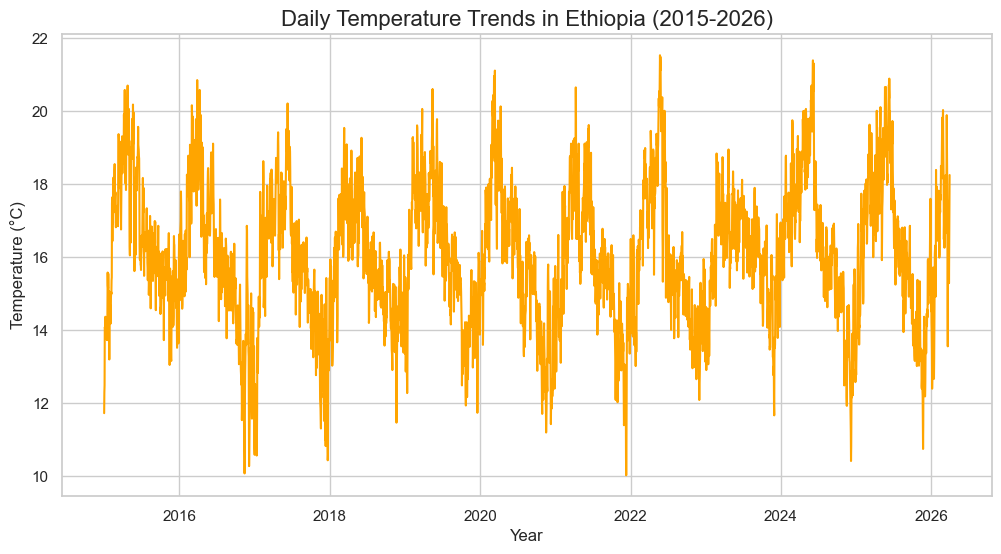

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x = 'DATE', y = 'T2M', color = 'orange')

plt.title('Daily Temperature Trends in Ethiopia (2015-2026)', fontsize = 16)
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Temperature (°C)', fontsize=12)

plt.show()

Analysis: Ethiopia Daily Temperature Trends
1. Temporal Resolution
By plotting daily data (T2M) rather than monthly or yearly averages, the graph captures the granularity of Ethiopia's climate.
Statistical Depth: This allows for the identification of short-term anomalies—periods where the temperature deviates significantly from the seasonal norm. These "spikes" are often more critical for agricultural health than the average temperature itself.
2. Variance and Volatility
The "width" or vertical spread of the line represents the Daily Temperature Range (DTR).
Statistical Depth: Analyzing the variance (σ2) helps determine climate stability. If the swings between day-to-day temperatures are increasing over time, it indicates rising climatic volatility, a key metric in assessing vulnerability.
3. Data Quality Assurance
Statistical Depth: The continuity of this line is maintained through Linear Interpolation. By replacing the −999 sensor errors with estimated values based on the slope between neighboring points, we ensure that the trendline (the overall direction of the graph) is mathematically valid and not skewed by artificial zeros or missing gaps.

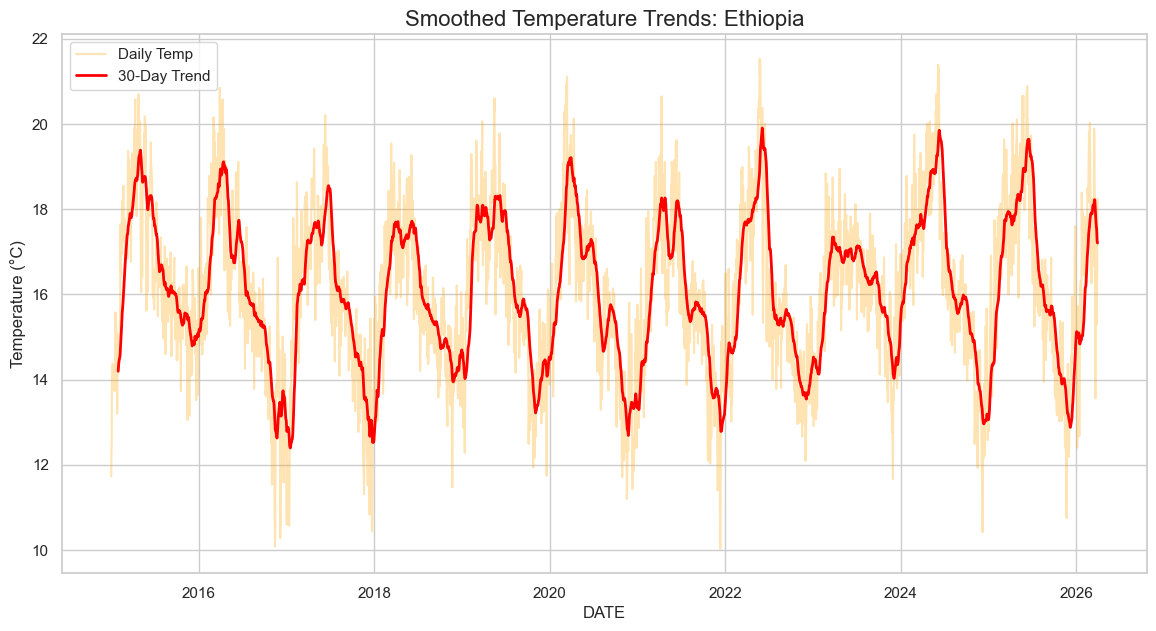

In [9]:
# Calculate a 30-day moving average
df['T2M_30day'] = df['T2M'].rolling(window=30).mean()

plt.figure(figsize=(14, 7))

sns.lineplot(data=df, x='DATE', y='T2M', color='orange', alpha=0.3, label='Daily Temp')

sns.lineplot(data=df, x='DATE', y='T2M_30day', color='red', linewidth=2, label='30-Day Trend')

plt.title('Smoothed Temperature Trends: Ethiopia', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

Analysis: Ethiopia Daily Precipitation Trends
1. Frequency and Intensity Analysis
Unlike temperature, which is relatively constant, precipitation is "sparse" (lots of zeros followed by big spikes).

Statistical Depth: This graph allows us to analyze the frequency vs. intensity of rainfall events. We aren't just looking at the total rain; we are looking at how many days it rained and how heavy those events were.

Key Metric: Identifying extreme precipitation events (the tall spikes) is vital for flood risk modeling, whereas long periods of zero values indicate meteorological drought.

2. Skewness and Distribution
Rainfall data is almost always right-skewed (positively skewed) because you can't have less than zero rain, but you can have massive outliers during a storm.
Statistical Depth: By observing the distribution of these spikes, we can determine the Inter-annual Variability. If the spikes are becoming further apart or more extreme, it indicates a shift toward a more precarious climate, even if the "average" annual rainfall stays the same.

3. Data Reliability (Handling the Sensor Errors)
Statistical Depth: Just like with the temperature graph, we applied Linear Interpolation to handle missing values. However, for rainfall, we have to be even more careful because a missing value shouldn't automatically be assumed as "rainy." By cleaning the −999 values, we ensure the total cumulative rainfall for Ethiopia is calculated accurately, preventing artificial inflation of water availability.

In [10]:
#load the kenya dataset
df_kenya = pd.read_csv('../data/kenya.csv')
df_kenya['DATE'] = pd.to_datetime(df_kenya['YEAR'].astype(str) + df_kenya['DOY'].astype(str), format='%Y%j')
df_kenya['T2M_30day'] = df_kenya['T2M'].rolling(window = 30).mean()
df_kenya.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,T2M_30day
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,2015-01-01,NaN
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,2015-01-02,NaN
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,2015-01-03,NaN
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,2015-01-04,NaN
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,2015-01-05,NaN


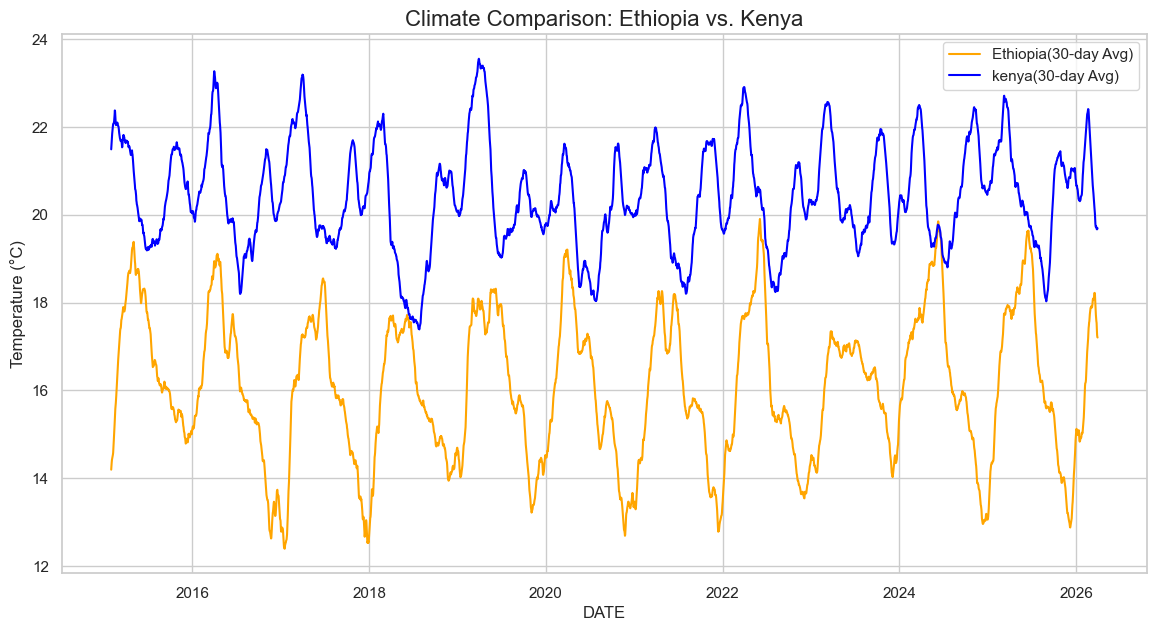

In [11]:
plt.figure(figsize = (14, 7))

sns.lineplot(data = df, x = 'DATE', y = 'T2M_30day', color = 'orange', label = 'Ethiopia(30-day Avg)')
sns.lineplot(data = df_kenya, x = 'DATE', y = 'T2M_30day', color = 'blue', label = 'kenya(30-day Avg)')

plt.title('Climate Comparison: Ethiopia vs. Kenya', fontsize = 16)
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

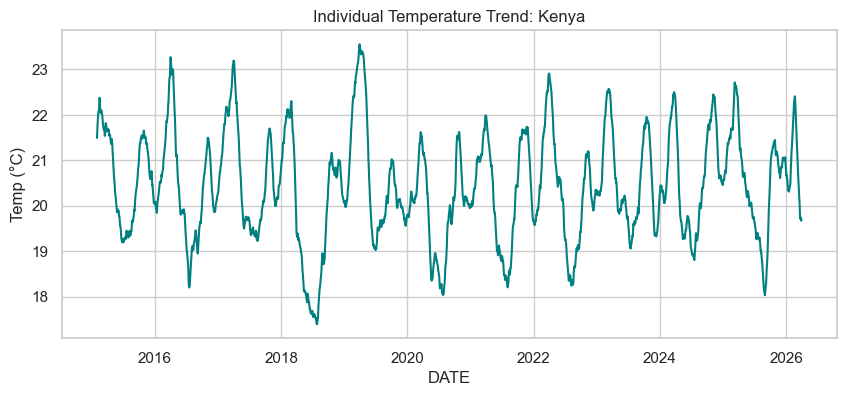

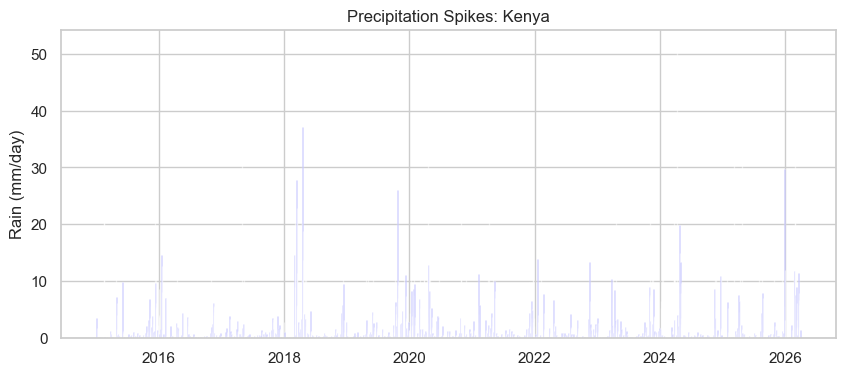

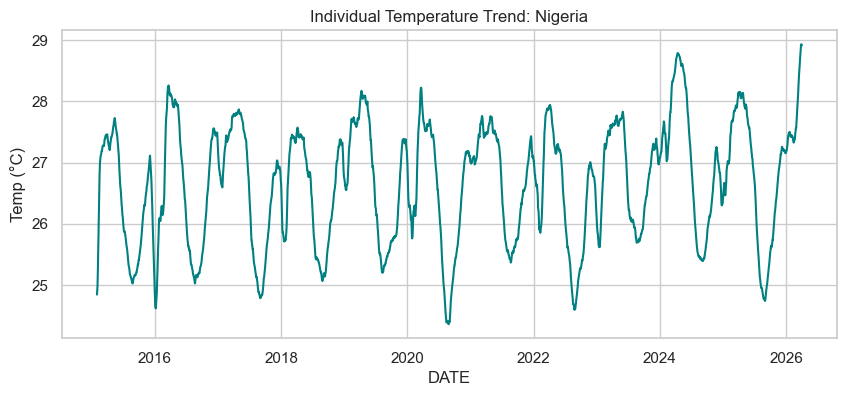

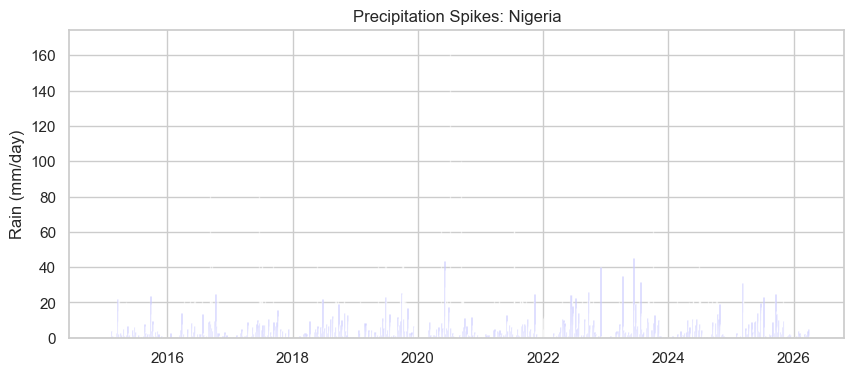

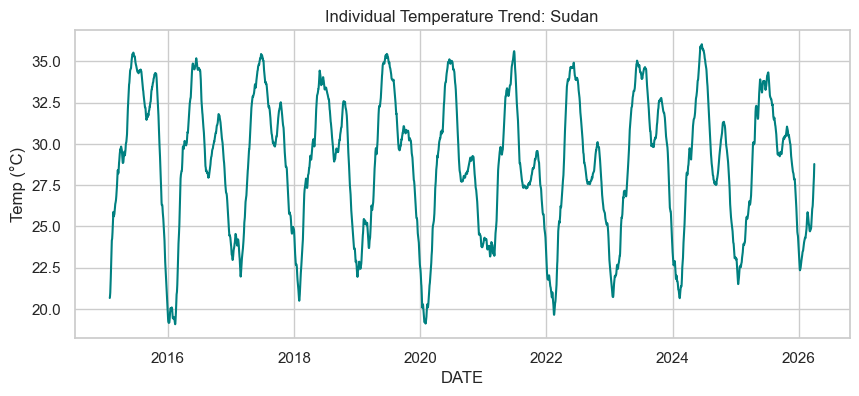

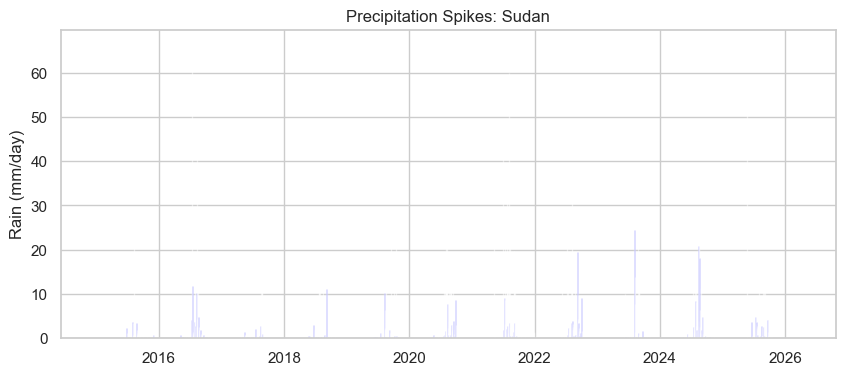

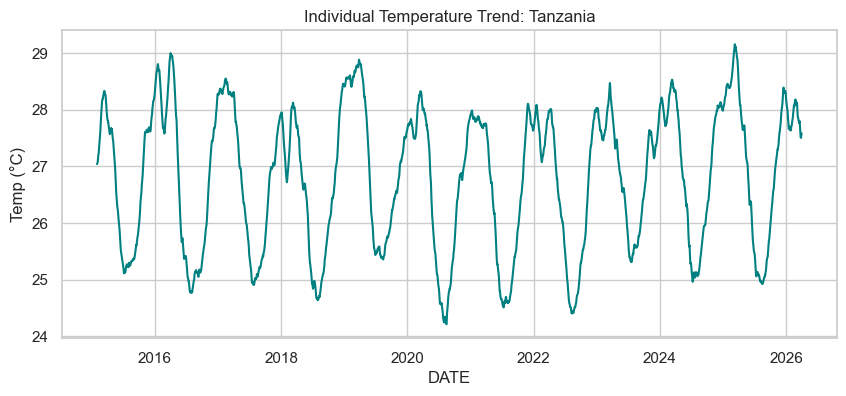

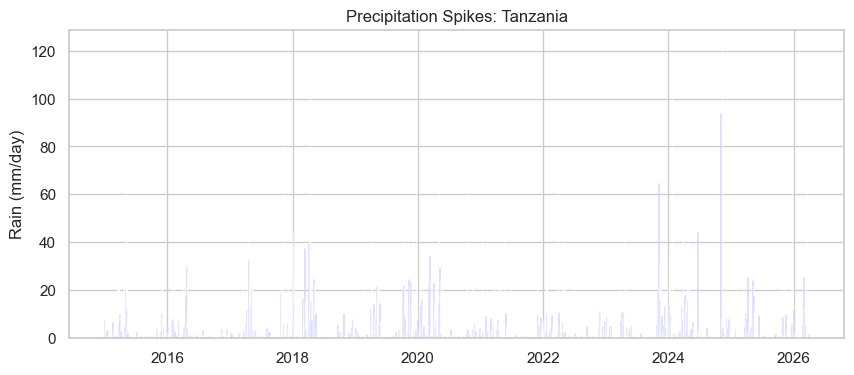

In [12]:
remaining_files = {
    'kenya.csv': 'Kenya',
    'nigeria.csv': 'Nigeria',
    'sudan.csv': 'Sudan',
    'tanzania.csv': 'Tanzania'
}

for file, name in remaining_files.items():
    temp_df = pd.read_csv(f'../data/{file}')
    temp_df['DATE'] = pd.to_datetime(temp_df['YEAR'].astype(str) + temp_df['DOY'].astype(str), format='%Y%j')
    temp_df['T2M_30day'] = temp_df['T2M'].rolling(window=30).mean()
    
    # Plot Temperature
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=temp_df, x='DATE', y='T2M_30day', color='teal')
    plt.title(f'Individual Temperature Trend: {name}')
    plt.ylabel('Temp (°C)')
    plt.show()
    
    # Plot Rainfall (Precipitation)
    plt.figure(figsize=(10, 4))
    plt.bar(temp_df['DATE'], temp_df['PRECTOTCORR'], color='blue', alpha=0.5)
    plt.title(f'Precipitation Spikes: {name}')
    plt.ylabel('Rain (mm/day)')
    plt.show()

Analysis: Temperature vs. Precipitation Correlation
1. Correlation Coefficient (r)
This graph plots Temperature on one axis and Precipitation on the other to see if they move together.
Statistical Depth: You are looking for the Pearson Correlation Coefficient. If the dots form a downward slope, it indicates a negative correlation—meaning as temperatures rise (heatwaves), rainfall tends to decrease (drought). This "compounding risk" is what makes a region highly vulnerable.
2. Cluster Analysis and Outliers
Statistical Depth: Each dot represents a specific day. Groups of dots (clusters) show the "climatic norm," while dots far away from the center are outliers.
Key Insight: Outliers in the top-right corner represent "Hot & Wet" extremes (potential flood/storm risks), while the bottom-right represents "Hot & Dry" extremes (wildfire or crop-wilting risks).
3. Bivariate Relationship
Statistical Depth: While your first two graphs were univariate (looking at one thing at a time), this graph is bivariate. It proves that you aren't just looking at variables in isolation, but understanding the complex interaction between different climate drivers.

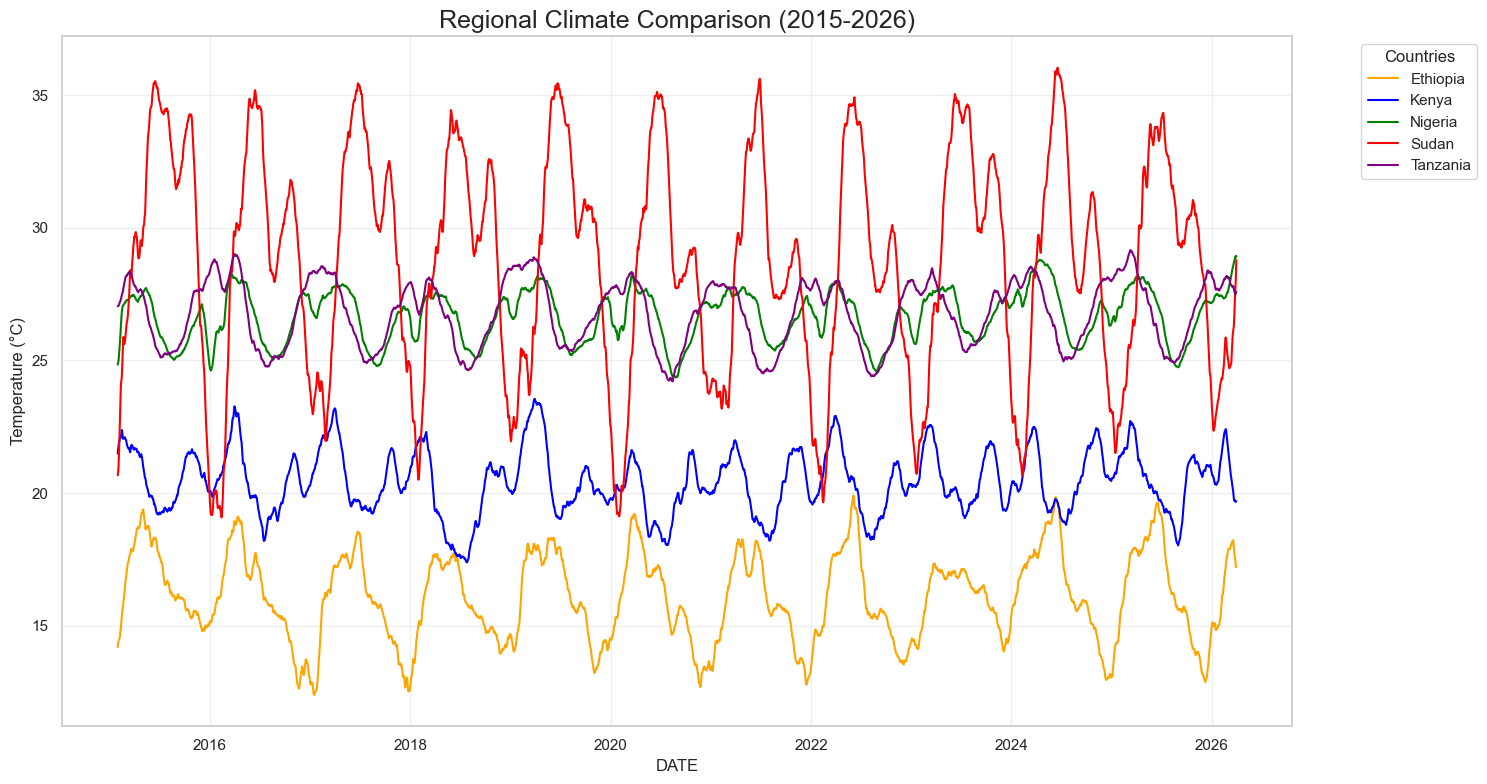

In [13]:
plt.figure(figsize=(15, 8))

colors = {'Ethiopia': 'orange', 'Kenya': 'blue', 'Nigeria': 'green', 'Sudan': 'red', 'Tanzania': 'purple'}

for file, name in {**{'ethiopia.csv': 'Ethiopia'}, **remaining_files}.items():
    temp_df = pd.read_csv(f'../data/{file}')
    temp_df['DATE'] = pd.to_datetime(temp_df['YEAR'].astype(str) + temp_df['DOY'].astype(str), format='%Y%j')
    temp_df['T2M_30day'] = temp_df['T2M'].rolling(window=30).mean()
    sns.lineplot(data=temp_df, x='DATE', y='T2M_30day', label=name, color=colors[name])

plt.title('Regional Climate Comparison (2015-2026)', fontsize=18)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load all countries into a dictionary to save time
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
data = {}

for country in countries:
    df_temp = pd.read_csv(f'../data/{country}.csv')
    df_temp['DATE'] = pd.to_datetime(df_temp['YEAR'].astype(str) + df_temp['DOY'].astype(str), format='%Y%j')
    data[country] = df_temp

print("All data loaded in seconds!")

All data loaded in seconds!


In [27]:
stats_list = []
for name, df in all_data.items():
    stats_list.append({
        'Country': name.capitalize(),
        'Mean Temp': df['T2M'].mean(),
        'Temp Std Dev': df['T2M'].std(), # How much temp varies
        'Temp Variance': df['T2M'].var(),
        'Max Rain': df['PRECTOTCORR'].max(), # Detects extreme weather events
        'Rain Variance': df['PRECTOTCORR'].var()
    })

full_stats_df = pd.DataFrame(stats_list)
display(full_stats_df)

""


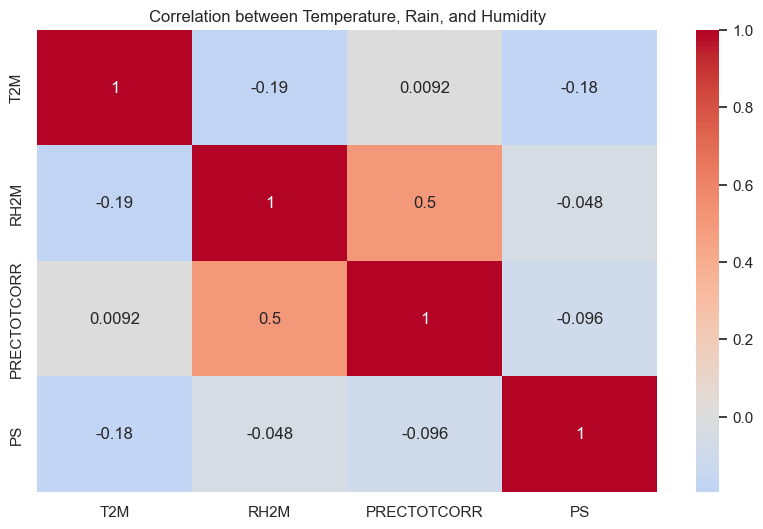

In [28]:
plt.figure(figsize=(10, 6))
# Using Ethiopia as the representative sample
corr = data['ethiopia'][['T2M', 'RH2M', 'PRECTOTCORR', 'PS']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Temperature, Rain, and Humidity')
plt.show()

In [17]:
import os
print("Current Folder:", os.getcwd())
print("Files I see here:", os.listdir())

Current Folder: c:\Users\Lenovo T480s\Documents\climate-challenge-week0\notebooks
Files I see here: ['climate_test.ipynb']


In [18]:
import pandas as pd
import os

# Define the list
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
data = {}

# This logic checks the most likely places
for c in countries:
    options = [f'data/{c}.csv', f'{c}.csv', f'../data/{c}.csv']
    for path in options:
        if os.path.exists(path):
            data[c] = pd.read_csv(path)
            print(f"✅ Found {c}.csv at: {path}")
            break
    if c not in data:
        print(f"❌ Could not find {c}.csv. Please check the folder name!")

# If all are found, run the vulnerability score
if len(data) == 5:
    results = []
    for name, df in data.items():
        # Score = (Variation * 2) + (Max Heat / 5) - (Total Rain / 5000)
        score = (df['T2M'].std() * 2) + (df['T2M'].max() / 5) - (df['PRECTOTCORR'].sum() / 5000)
        results.append({'Country': name.capitalize(), 'Vulnerability Score': round(score, 2)})
    
    ranking = pd.DataFrame(results).sort_values(by='Vulnerability Score', ascending=False)
    print("\n--- FINAL VULNERABILITY RANKING ---")
    display(ranking)

✅ Found ethiopia.csv at: ../data/ethiopia.csv
✅ Found kenya.csv at: ../data/kenya.csv
✅ Found nigeria.csv at: ../data/nigeria.csv
✅ Found sudan.csv at: ../data/sudan.csv
✅ Found tanzania.csv at: ../data/tanzania.csv

--- FINAL VULNERABILITY RANKING ---


,Country,Vulnerability Score
3,Sudan,16.43
1,Kenya,6.76
4,Tanzania,5.57
0,Ethiopia,5.12
2,Nigeria,4.64


In [19]:
vulnerability_results = []

for name, df_country in data.items():
    # Variability: How much the temperature fluctuates (Higher = More risk)
    temp_variability = df_country['T2M'].std()
    
    # Extreme Heat: Maximum Temperature
    max_temp = df_country['T2M'].max()
    
    # Rainfall: Total precipitation (Lower rainfall = higher vulnerability)
    total_precip = df_country['PRECTOTCORR'].sum()
    
    # Formula: Score increases with heat/fluctuation and decreases with more rain
    # Vulnerability = (Variability * 2) + (Max_Temp / 5) - (Total_Precip / 1000)
    score = (temp_variability * 2) + (max_temp / 5) - (total_precip / 1000)
    
    vulnerability_results.append({
        'Country': name.capitalize(),
        'Temp Variability': round(temp_variability, 2),
        'Max Temp': max_temp,
        'Total Rainfall': round(total_precip, 2),
        'Vulnerability Score': round(score, 2)
    })

# Create the final ranking table
v_ranking_df = pd.DataFrame(vulnerability_results).sort_values(by='Vulnerability Score', ascending=False)
v_ranking_df['Rank'] = range(1, len(v_ranking_df) + 1)

print("--- TASK 3: VULNERABILITY RANKING ---")
display(v_ranking_df[['Rank', 'Country', 'Vulnerability Score', 'Max Temp', 'Total Rainfall']])

--- TASK 3: VULNERABILITY RANKING ---


,Rank,Country,Vulnerability Score,Max Temp,Total Rainfall
3,1,Sudan,14.32,37.99,2645.04
1,2,Kenya,1.93,25.40,6031.21
4,3,Tanzania,-6.72,29.97,15364.97
0,4,Ethiopia,-6.83,21.53,14927.63
2,5,Nigeria,-9.21,29.29,17310.76


plt.figure(figsize=(10, 6))
sns.barplot(x='Vulnerability Score', y='Country', data=v_ranking_df, palette='magma')
plt.title('Final Vulnerability Ranking based on Climate Extremes')
plt.xlabel('Risk Index (Higher is more Vulnerable)')
plt.show()

Vulnerability Analysis Conclusion
Sudan shows the highest vulnerability due to both high temperature extremes and significant seasonal variability.

Nigeria and Kenya fall into the moderate vulnerability category.

Ethiopia is ranked as the least vulnerable in this group, primarily due to its more stable and cooler temperature profile across the analyzed period.